In [1]:
import pandas as pd
import re
import math
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
from scipy import stats
import datetime
import seaborn as sns
from geopy.distance import distance
import geopandas as gpd
import rioxarray
from functools import reduce
import warnings
warnings.filterwarnings('ignore')

In [2]:
def detrend(ts):

    for i in range(len(ts)):
        if np.isnan(ts[i]):
            ts[i] = np.nanmean(ts)
            
    X = np.array([[1,i] for i in range(len(ts))])
    y = np.array(ts)
    
    ols = sm.OLS(y, X, missing = 'drop')
    ols_model = ols.fit()

    fit = ols_model.predict()

    new_ts = []
    for i in range(len(ts)):
        new_ts.append(ts[i] - (fit[i]-ts[0]))
    
    #plt.plot(y)
    #plt.plot(new_ts)
    #plt.plot(fit)
    
    return new_ts


In [4]:
monthly_msl_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/M1_range_mslp/1969_2019.nc')


In [5]:
monthly_msl_ds

<xarray.Dataset>
Dimensions:    (latitude: 61, longitude: 225, time: 612)
Coordinates:
  * latitude   (latitude) float32 -33.0 -33.25 -33.5 ... -47.5 -47.75 -48.0
  * longitude  (longitude) float32 144.0 144.25 144.5 ... 199.5 199.75 200.0
  * time       (time) datetime64[ns] 1969-01-01 1969-02-01 ... 2019-12-01
Data variables:
    msl        (time, latitude, longitude) float32 ...
    tcrw       (time, latitude, longitude) float32 ...
    tcsw       (time, latitude, longitude) float32 ...
    tp         (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      Sun Sep 26 06:05:19 2021: ncrcat temp/RD_1969.nc 1970.nc 19...
    NCO:          netCDF Operators version 4.8.1 (Homepage = http://nco.sf.ne...

In [3]:
# load ERA5 data

# extended study area to include Tasmania for M1
monthly_msl_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/M1_range_mslp/1969_2019.nc')

# NZ only study area data
monthly_misc = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/1969_2019_all.nc')
monthly_snow = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/1959_2021.nc').sel(time=slice('1969', '2019'))
monthly_temp = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/temp/1959_2019.nc').sel(time=slice('1969', '2019'))
monthly_snowmelt = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/snowmelt/1969_2019.nc').sel(time=slice('1969', '2019'))
monthly_runoff = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/runoff/total_runoff/1969_2019.nc').sel(time=slice('1969', '2019'))

monthly_era = xr.merge([monthly_misc,monthly_snow,monthly_temp,monthly_snowmelt,monthly_runoff])

seasonal_era = monthly_era.resample(time='Q-DEC').mean()

# interpolate ERA5 to finer spatial resolution
new_lon = np.linspace(seasonal_era.longitude[0], seasonal_era.longitude[-1], len(seasonal_era.longitude.values) * 10)
new_lat = np.linspace(seasonal_era.latitude[0], seasonal_era.latitude[-1], len(seasonal_era.latitude.values) * 10)

seasonal_era_interp = seasonal_era.interp(latitude=new_lat, longitude=new_lon,method='linear')

'''
# load MONTHLY observed flow data
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv')
flow_df.Date = pd.to_datetime(flow_df.Date)
flow_df.set_index('Date', inplace=True)
flow_df = flow_df['1969':'2019']
monthly_flow_df = flow_df.resample('M').mean()
monthly_flow_df.index=monthly_flow_df.index.map(lambda x : x.replace(day=1))
#monthly_flow_df.fillna(monthly_flow_df.mean(), inplace=True)
'''

# load SEASONAL observed flow data
seasonal_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)
seasonal_flow_df = seasonal_flow_df['1969':'2019'] 

# load metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [4]:
'''
Create pressure differential time series of anomalies between Auckland and Christchurch (Z1) 
                and Hobart and the Chatham Islands (M1)
'''

msl_da = monthly_msl_ds['msl']

# find cells with coordinates nearest to Auckland and Christchurch

akl_coords = (-36.85, 174.76)
chch_coords = (-43.53, 172.63)
hobart_coords = (-42.88, 147.32)
chatham_coords = (-44, 183.46)

akl_ts_monthly = msl_da.sel(latitude=akl_coords[0],longitude=akl_coords[1],method='nearest')
chch_ts_monthly = msl_da.sel(latitude=chch_coords[0],longitude=chch_coords[1],method='nearest')
hobart_ts_monthly = msl_da.sel(latitude=hobart_coords[0],longitude=hobart_coords[1],method='nearest')
chatham_ts_monthly = msl_da.sel(latitude=chatham_coords[0],longitude=chatham_coords[1],method='nearest')

msl_df = pd.DataFrame.from_dict({'akl':akl_ts_monthly.values.tolist(),
                                 'chch':chch_ts_monthly.values.tolist(),
                                 'hobart':hobart_ts_monthly.values.tolist(),
                                 'chatham':chatham_ts_monthly.values.tolist(),
                                 'date':akl_ts_monthly.time.values.tolist()})

msl_df['Z1'] = msl_df['akl'] - msl_df['chch']
msl_df['M1'] = msl_df['hobart'] - msl_df['chatham']

msl_df.date = pd.to_datetime(msl_df.date)
msl_df.set_index('date', inplace=True)

msl_ts = msl_df[['Z1','M1']]
seasonal_msl_ts = msl_ts.resample('Q-DEC').mean()
seasonal_msl_ts.index = [pd.to_datetime(x).replace(day=1) for x in seasonal_msl_ts.index]


(-47, -35)

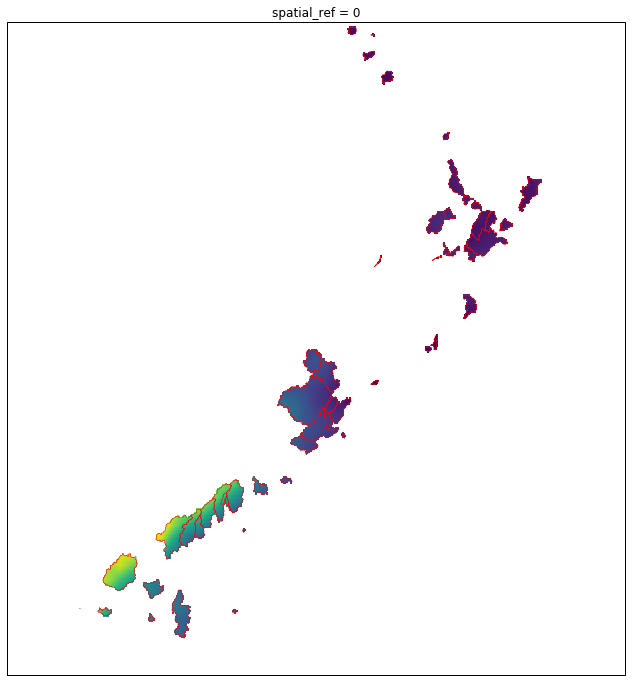

In [6]:
index = 'tcsw'
crs = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(16,12),subplot_kw={'projection': crs})

da = seasonal_era_interp[index].rio.write_crs("EPSG:4326")
da.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

clipped = da.rio.clip(catchment_data.geometry,catchment_data.crs)

clipped.mean('time').plot.pcolormesh(ax=ax, transform=crs,add_colorbar=False)
catchment_data.plot(ax=ax,color='',edgecolor='red',linewidth=0.4,alpha=1)

#ax.coastlines(transform=crs,resolution='50m', color='black', linewidth=1, alpha=1)
ax.set_xlim(165,180)
ax.set_ylim(-47,-35)

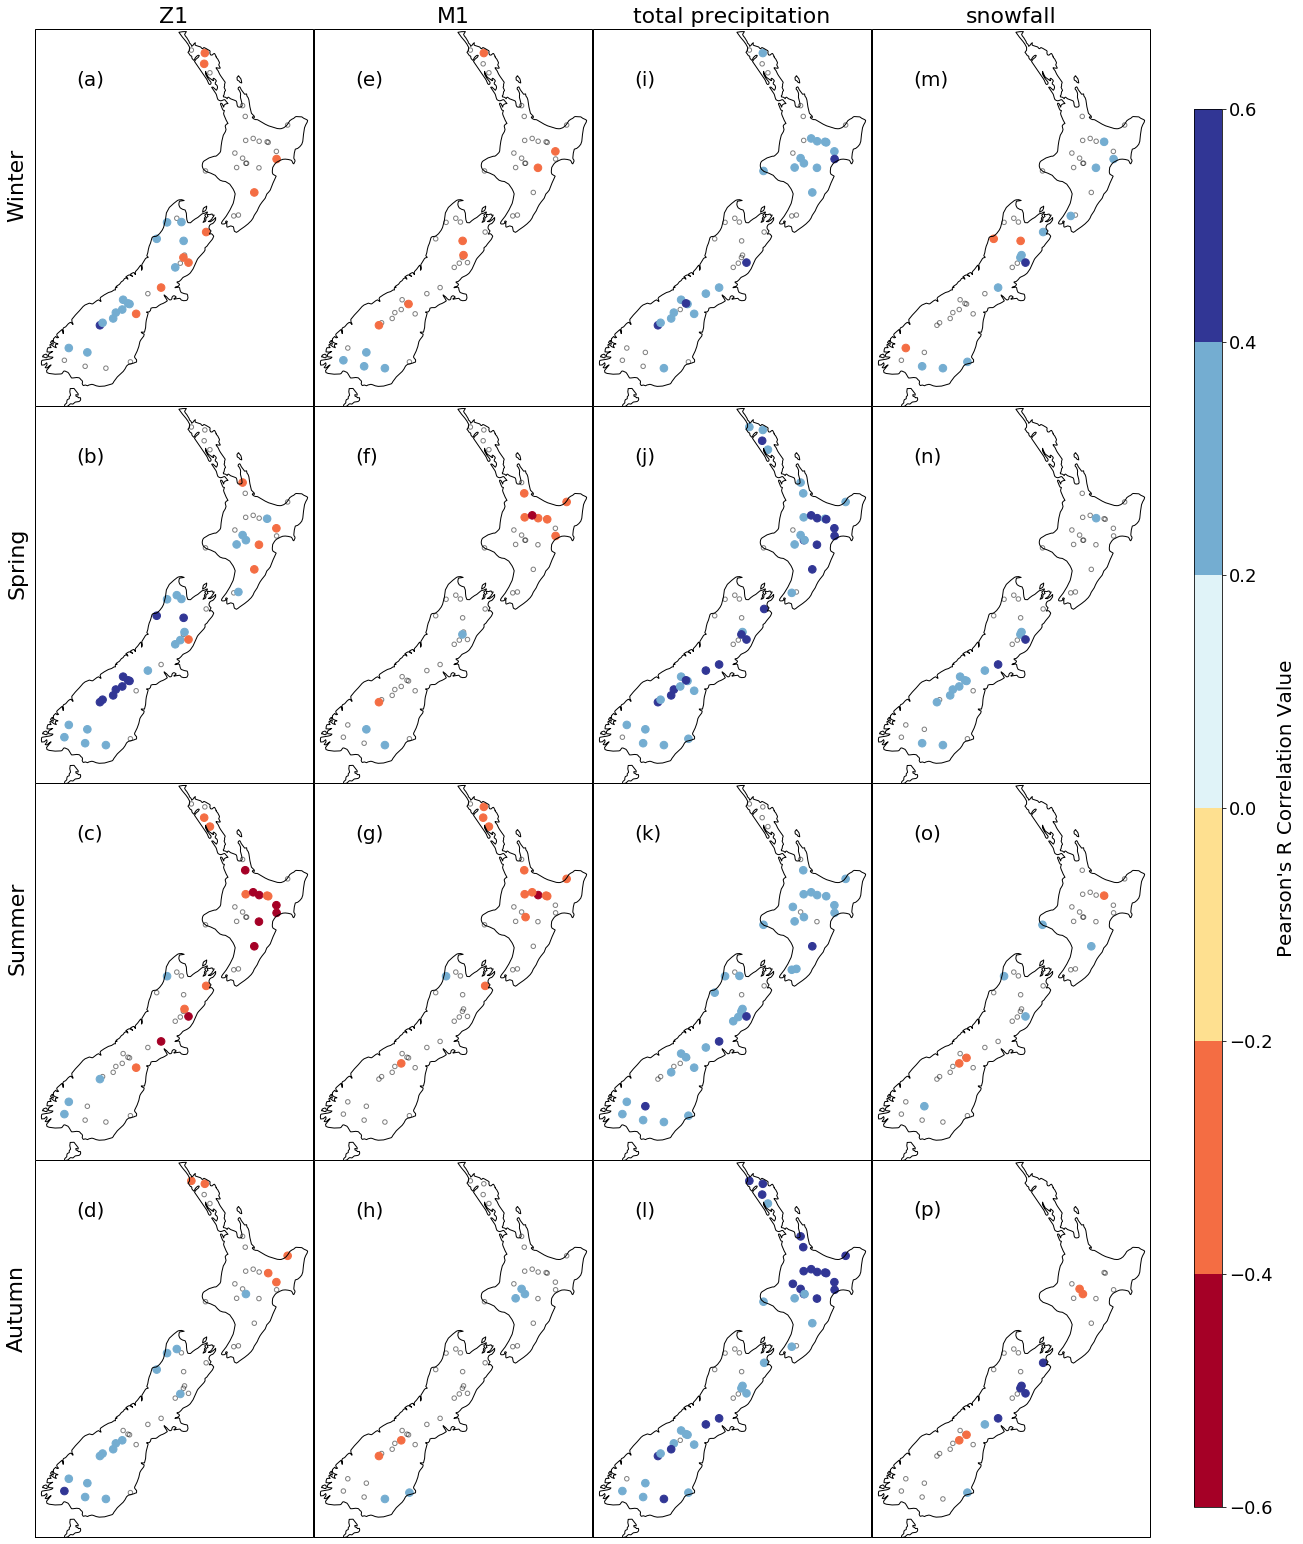

In [6]:
'''
SEASONAL correlations with interpolated ERA5 data
'''

crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
#catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(4,4,figsize=(20,27.735),subplot_kw={'projection': crs})

indices = ['Z1','M1','tp','sf']
alpha = ['a','e','i','m',
         'b','f','j','n',
         'c','g','k','o',
         'd','h','l','p','q']
ax_count = 0
for i,s in enumerate([6,9,12,3]):
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]
    era_season = seasonal_era_interp.sel(time=seasonal_era_interp.time.dt.month.isin([s]))
        
    for j,index in enumerate(indices):
        
        if index in ['Z1','M1']:
            msl_season = seasonal_msl_ts[index][seasonal_msl_ts.index.month == s]['1969':'2019']
            
        else:
            era_index = era_season[index].rio.write_crs("EPSG:4326")
            era_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

        sig_lons = []
        sig_lats = []
        sig_corr = []
        
        non_lons = []
        non_lats = []
        non_corr = []
        
        for site in flow_season:

            if site == '4901':
                continue
                
            detrended_flow = detrend(flow_season[site])
                
            if index in ['Z1','M1']:
                (r,p) = stats.pearsonr(detrended_flow,msl_season.values.tolist())
            else:
                catchment_geo = catchment_data.loc[[float(site)]]
                clipped_era = era_index.rio.clip(catchment_geo.geometry,catchment_data.crs)
            
                clipped_ts = clipped_era.mean(['longitude','latitude']).values.tolist()

                (r,p) = stats.pearsonr(detrended_flow,clipped_ts)

            if p > 0.15:
                non_corr.append(r)
                non_lats.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1])
                non_lons.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0])
            
            else:
                sig_corr.append(r)
                sig_lats.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1])
                sig_lons.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0])
        
        axs[i][j].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
        axs[i][j].set_xlim([18500000,19900000])
        axs[i][j].set_ylim([-5950000,-4050000])
        
        axs[i][j].text(.15,.85,"(" + alpha[ax_count] + ")", transform = axs[i][j].transAxes,fontsize=20)
        ax_count += 1
        
        im = axs[i][j].scatter(non_lons,non_lats,marker='.',s=80,facecolor='',edgecolor='black',alpha=0.5)
        im = axs[i][j].scatter(sig_lons,sig_lats,marker='.',s=230,c=sig_corr,cmap=plt.cm.get_cmap('RdYlBu', 6),vmin=-0.6,vmax=0.6)

        if j == 0:
            axs[i][j].text(-0.1,0.5,{3:'Autumn',6:'Winter',9:'Spring',12:'Summer'}[s],
                           rotation='vertical',transform=axs[i][j].transAxes,
                           fontsize=22)
            
        if i == 0:
            axs[i][j].set_title(index if index in ['Z1','M1'] else {'tp':'total precipitation','sf':'snowfall'}[index], fontsize=22)
            
cax = fig.add_axes([.93,0.14,.02,.7])
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Pearson\'s R Correlation Value',size=20)

plt.subplots_adjust(wspace=0, hspace=0)
        
plt.savefig("Figure8_interp.png",dpi=300,bbox_inches='tight')


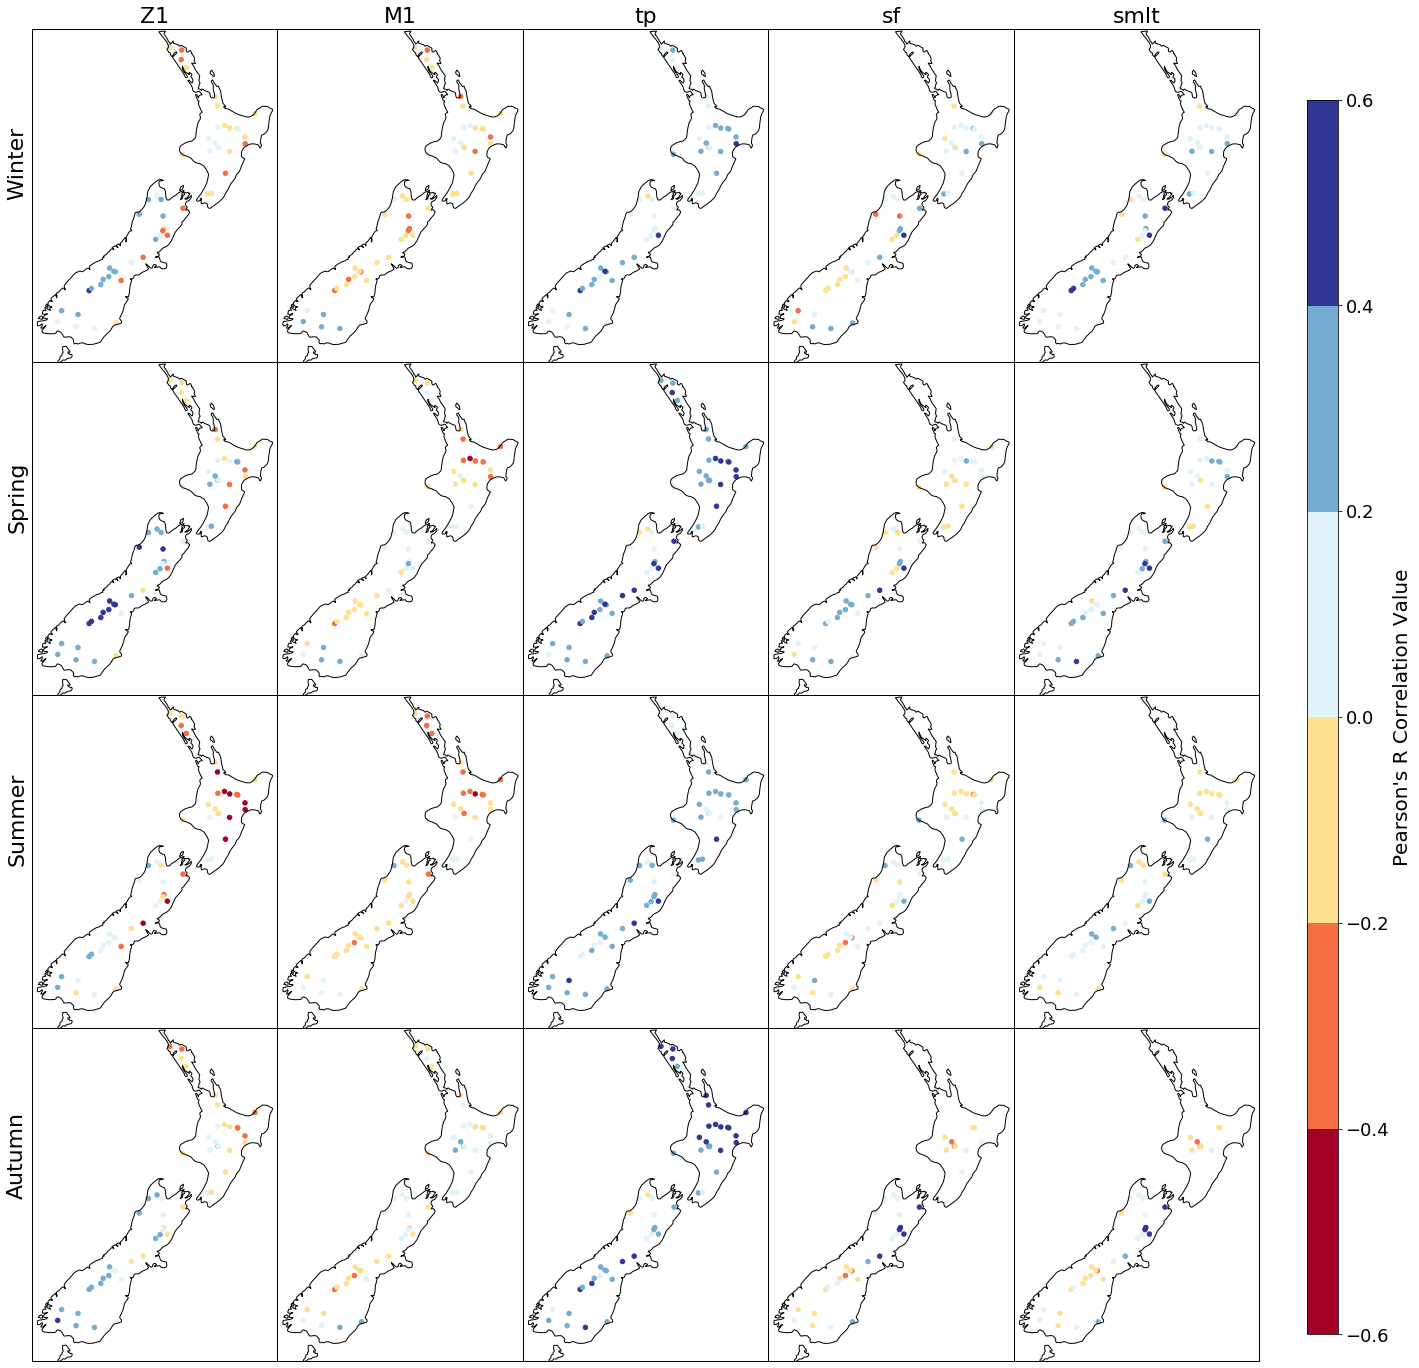

In [7]:
'''
SEASONAL correlations with interpolated ERA5 data
'''

crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
#catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(4,5,figsize=(22,24.5),subplot_kw={'projection': crs})

indices = ['Z1','M1','tp','sf','smlt']

for i,s in enumerate([6,9,12,3]):
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]
    era_season = seasonal_era_interp.sel(time=seasonal_era_interp.time.dt.month.isin([s]))
        
    for j,index in enumerate(indices):
        
        if index in ['Z1','M1']:
            msl_season = seasonal_msl_ts[index][seasonal_msl_ts.index.month == s]['1969':'2019']
            
        else:
            era_index = era_season[index].rio.write_crs("EPSG:4326")
            era_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

        lons = []
        lats = []
        corr = []
        
        for site in flow_season:

            if site == '4901':
                continue
                
            detrended_flow = detrend(flow_season[site])
                
            if index in ['Z1','M1']:
                (r,p) = stats.pearsonr(detrended_flow,msl_season.values.tolist())
            else:
                catchment_geo = catchment_data.loc[[float(site)]]
                clipped_era = era_index.rio.clip(catchment_geo.geometry,catchment_data.crs)
            
                clipped_ts = clipped_era.mean(['longitude','latitude']).values.tolist()

                (r,p) = stats.pearsonr(detrended_flow,clipped_ts)
              
            corr.append(r)
            lats.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1])
            lons.append(meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0])
    
        axs[i][j].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
        axs[i][j].set_xlim([18500000,19900000])
        axs[i][j].set_ylim([-5950000,-4050000])

        im = axs[i][j].scatter(lons,lats,marker='.',s=80,c=corr,cmap=plt.cm.get_cmap('RdYlBu', 6),vmin=-0.6,vmax=0.6)

        if j == 0:
            axs[i][j].text(-0.1,0.5,{3:'Autumn',6:'Winter',9:'Spring',12:'Summer'}[s],
                           rotation='vertical',transform=axs[i][j].transAxes,
                           fontsize=22)
            
        if i == 0:
            axs[i][j].set_title(index, fontsize=22)
            
cax = fig.add_axes([.93,0.14,.02,.7])
cbar = fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Pearson\'s R Correlation Value',size=20)

plt.subplots_adjust(wspace=0, hspace=0)
        
#plt.savefig("Figure8_interp.png",dpi=300,bbox_inches='tight')


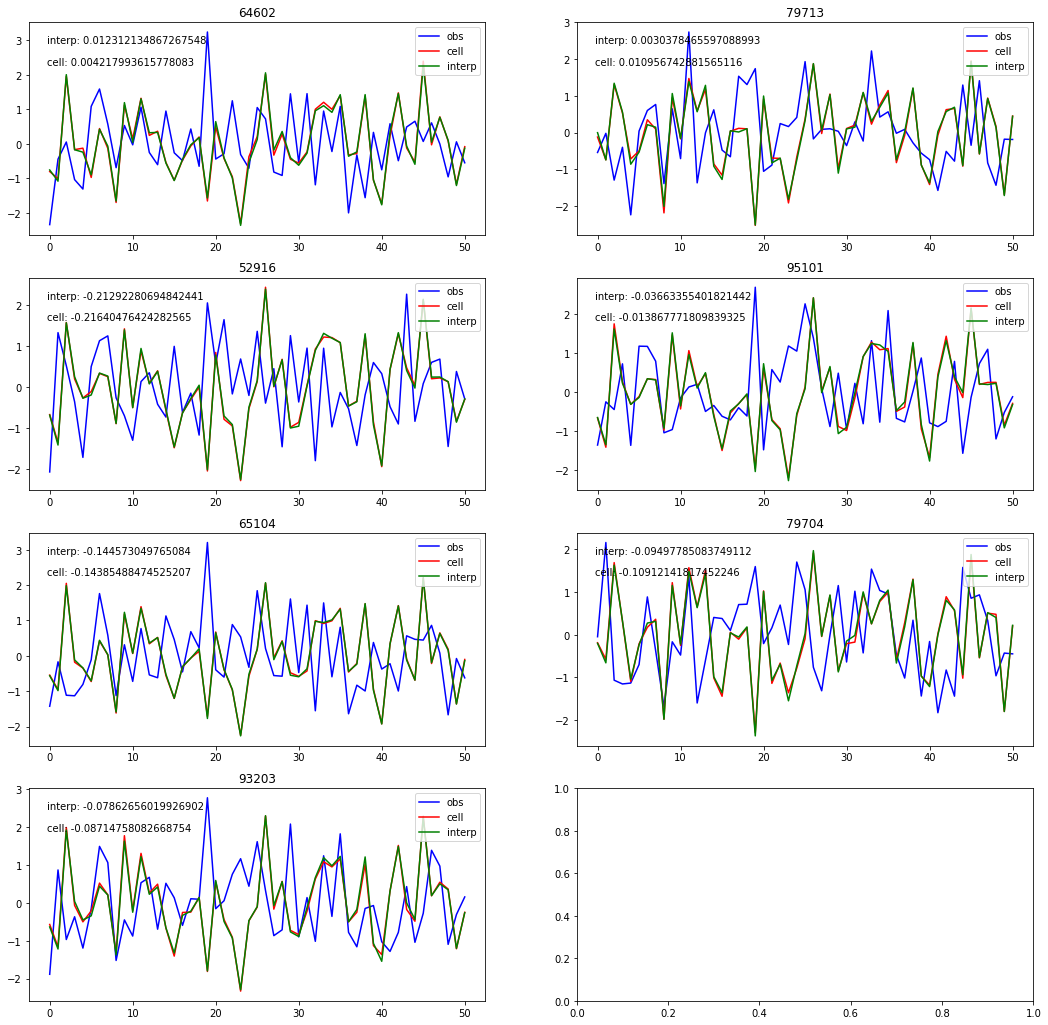

In [11]:
from scipy import stats

fig, ax = plt.subplots(4,2,figsize=(18,18))
axs = ax.flatten()

index = 't2m'#'tp','tcsw','sro']
era_index = seasonal_era[index]
era_interp_index = seasonal_era_interp[index].rio.write_crs("EPSG:4326")
era_interp_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for s in [6]:#,9,12,3]):
    era_season = era_index.sel(time=era_index.time.dt.month.isin([s]))
    era_interp_season = era_interp_index.sel(time=era_interp_index.time.dt.month.isin([s]))
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]['1969':'2019'] 
        
    for i,site in enumerate(['64602', '79713', '52916', '95101', '65104', '79704', '93203', ]):
        
        detrended_flow = detrend(flow_season[site].values.tolist())
        
        gauge_coords = [float(metadata_df.loc[int(site)]['centroid_lat']),float(metadata_df.loc[int(site)]['centroid_lon'])]

        cell = era_season.sel(latitude=gauge_coords[0],longitude=gauge_coords[1],method='nearest')
        
        catchment_geo = catchment_data.loc[[float(site)]]
        clipped_era = era_interp_season.rio.clip(catchment_geo.geometry,catchment_data.crs)
        
        cell_ts = cell.values.tolist()
        #print(cell_ts)
        #print(flow_season[site].values.tolist())
        cell_ts = (cell_ts - np.mean(cell_ts))/np.std(cell_ts)
        interp_ts = clipped_era.mean(['longitude','latitude']).values.tolist()
        interp_ts = (interp_ts - np.mean(interp_ts))/np.std(interp_ts)
        detrended_flow = (detrended_flow - np.mean(detrended_flow))/np.std(detrended_flow)
        
        axs[i].plot(detrended_flow,color='blue',label='obs')
        axs[i].plot(cell_ts,color='red',label='cell')
        axs[i].plot(interp_ts,color='green',label='interp')
        
        (r1,p1) = stats.pearsonr(detrended_flow, cell.values.tolist())
        (r2,p2) = stats.pearsonr(detrended_flow, interp_ts)

        axs[i].text(0.04,0.8,"cell: " + str(r1), transform=axs[i].transAxes)
        axs[i].text(0.04,0.9,"interp: " + str(r2), transform=axs[i].transAxes)

        axs[i].set_title(site)
        
        axs[i].legend(loc='upper right')
    



